In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
results = pd.read_csv("data/LightGBM_all_months_forecast_results.csv")

In [3]:
results.head()

,Product_Name,month_idx,Actual_Min_Price_next,Predicted_Min_Price_next,Actual_Avg_Price_next,Predicted_Avg_Price_next,Actual_Max_Price_next,Predicted_Max_Price_next
0,Akabary_Chilly,1,300.0,263.90,628.57,424.52,900.0,577.11
1,Akabary_Chilly,2,300.0,362.07,555.56,516.70,800.0,624.84
2,Akabary_Chilly,3,300.0,362.13,439.77,493.93,500.0,570.46
3,Akabary_Chilly,4,400.0,394.84,450.00,477.57,500.0,530.13
4,Amala,1,100.0,139.07,111.25,157.73,120.0,179.39


In [4]:
results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 641 entries, 0 to 640
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Product_Name              641 non-null    object 
 1   month_idx                 641 non-null    int64  
 2   Actual_Min_Price_next     641 non-null    float64
 3   Predicted_Min_Price_next  641 non-null    float64
 4   Actual_Avg_Price_next     641 non-null    float64
 5   Predicted_Avg_Price_next  641 non-null    float64
 6   Actual_Max_Price_next     641 non-null    float64
 7   Predicted_Max_Price_next  641 non-null    float64
dtypes: float64(6), int64(1), object(1)
memory usage: 40.2+ KB


In [5]:
results["Min_Error"] = (
    results["Actual_Min_Price_next"] -
    results["Predicted_Min_Price_next"]
).abs()

results["Avg_Error"] = (
    results["Actual_Avg_Price_next"] -
    results["Predicted_Avg_Price_next"]
).abs()

results["Max_Error"] = (
    results["Actual_Max_Price_next"] -
    results["Predicted_Max_Price_next"]
).abs()

In [6]:
results[["Min_Error", "Avg_Error", "Max_Error"]].describe()

,Min_Error,Avg_Error,Max_Error
count,641.000000,641.000000,641.000000
mean,12.976240,16.549236,21.905257
std,26.220097,34.707782,45.077223
min,0.010000,0.010000,0.010000
25%,2.710000,3.020000,3.460000
50%,6.510000,7.320000,9.180000
75%,13.930000,16.840000,21.030000
max,416.970000,409.060000,661.960000


In [7]:
print(f"Mean Minimum Price Error : {results['Min_Error'].mean():.2f}")
print(f"Mean Average Price Error : {results['Avg_Error'].mean():.2f}")
print(f"Mean Maximum Price Error : {results['Max_Error'].mean():.2f}")

Mean Minimum Price Error : 12.98
Mean Average Price Error : 16.55
Mean Maximum Price Error : 21.91


In [8]:
results["Total_Error"] = (
    results["Min_Error"] +
    results["Avg_Error"] +
    results["Max_Error"]
)

results.head()

,Product_Name,month_idx,Actual_Min_Price_next,Predicted_Min_Price_next,Actual_Avg_Price_next,Predicted_Avg_Price_next,Actual_Max_Price_next,Predicted_Max_Price_next,Min_Error,Avg_Error,Max_Error,Total_Error
0,Akabary_Chilly,1,300.0,263.90,628.57,424.52,900.0,577.11,36.10,204.05,322.89,563.04
1,Akabary_Chilly,2,300.0,362.07,555.56,516.70,800.0,624.84,62.07,38.86,175.16,276.09
2,Akabary_Chilly,3,300.0,362.13,439.77,493.93,500.0,570.46,62.13,54.16,70.46,186.75
3,Akabary_Chilly,4,400.0,394.84,450.00,477.57,500.0,530.13,5.16,27.57,30.13,62.86
4,Amala,1,100.0,139.07,111.25,157.73,120.0,179.39,39.07,46.48,59.39,144.94


In [9]:
worst_cases = results.sort_values(
    by="Total_Error",
    ascending=False
).head(20)

worst_cases

,Product_Name,month_idx,Actual_Min_Price_next,Predicted_Min_Price_next,Actual_Avg_Price_next,Predicted_Avg_Price_next,Actual_Max_Price_next,Predicted_Max_Price_next,Min_Error,Avg_Error,Max_Error,Total_Error
571,Strawberry,1,700.0,283.03,700.00,327.29,700.0,365.09,416.97,372.71,334.91,1124.59
44,Avocado,9,650.0,308.60,757.61,348.55,800.0,460.11,341.40,409.06,339.89,1090.35
43,Avocado,8,300.0,314.01,721.43,324.50,1000.0,338.04,14.01,396.93,661.96,1072.90
0,Akabary_Chilly,1,300.0,263.90,628.57,424.52,900.0,577.11,36.10,204.05,322.89,563.04
154,Cabbage_Red,8,60.0,150.01,90.23,279.00,200.0,435.79,90.01,188.77,235.79,514.57
340,Lemon,9,250.0,145.46,363.04,182.69,450.0,248.79,104.54,180.35,201.21,486.10
316,Kiwi,1,300.0,271.05,613.59,396.44,800.0,565.89,28.95,217.15,234.11,480.21
339,Lemon,8,260.0,157.46,309.32,167.79,350.0,223.04,102.54,141.53,126.96,371.03
36,Avocado,1,300.0,261.60,400.00,307.93,600.0,385.82,38.40,92.07,214.18,344.65
359,Mombin,1,150.0,228.41,150.00,245.53,150.0,284.84,78.41,95.53,134.84,308.78


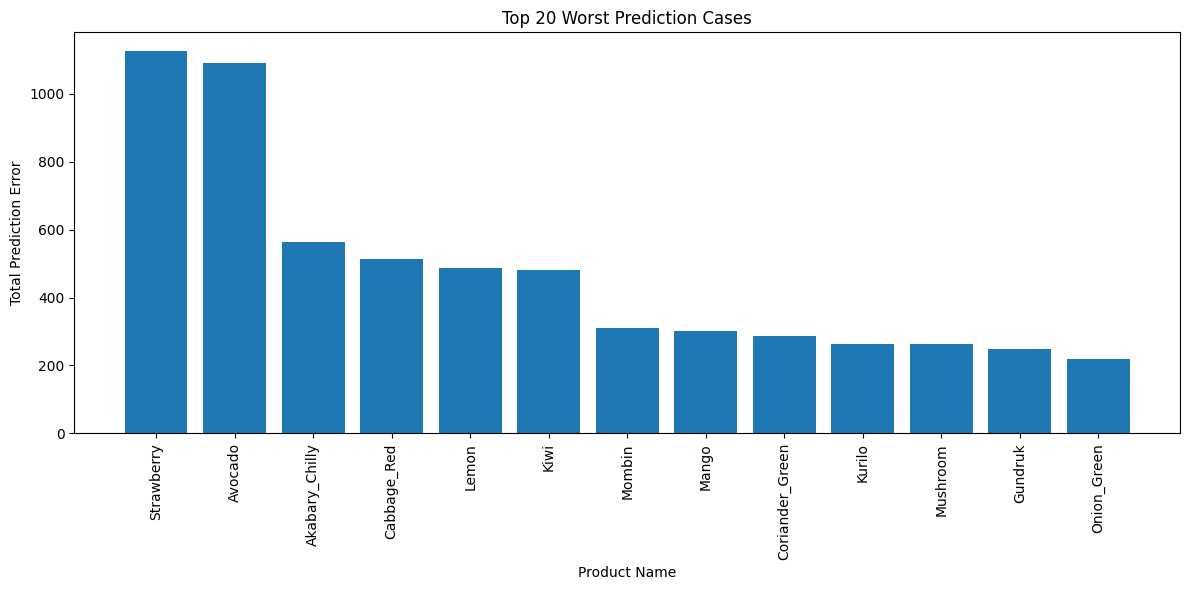

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    worst_cases["Product_Name"],
    worst_cases["Total_Error"]
)

plt.xticks(rotation=90)

plt.xlabel("Product Name")
plt.ylabel("Total Prediction Error")
plt.title("Top 20 Worst Prediction Cases")

plt.tight_layout()
plt.show()

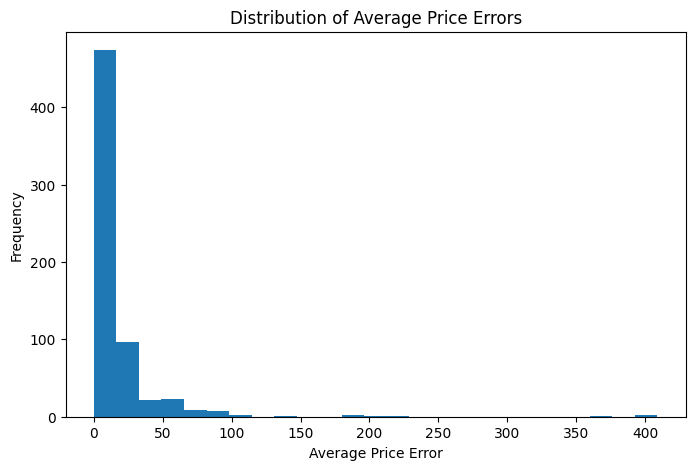

In [11]:
plt.figure(figsize=(8,5))

plt.hist(results["Avg_Error"], bins=25)

plt.xlabel("Average Price Error")
plt.ylabel("Frequency")
plt.title("Distribution of Average Price Errors")

plt.show()

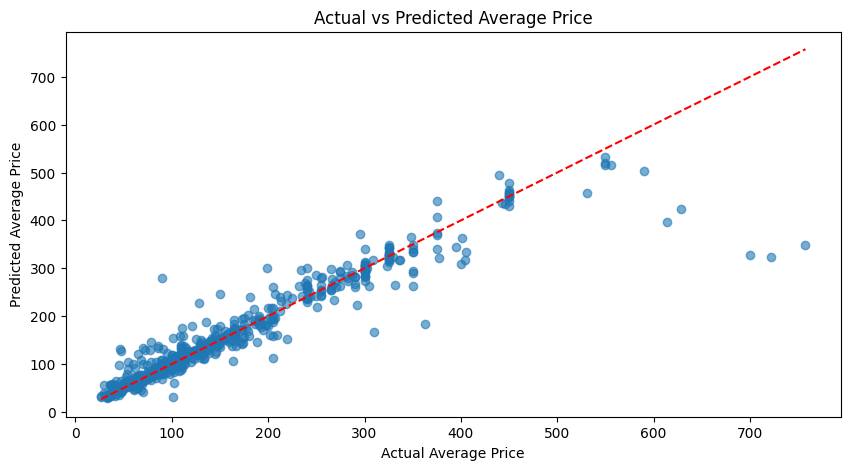

In [12]:
plt.figure(figsize=(10,5))

plt.scatter(
    results["Actual_Avg_Price_next"],
    results["Predicted_Avg_Price_next"],
    alpha=0.6
)

plt.plot(
    [
        results["Actual_Avg_Price_next"].min(),
        results["Actual_Avg_Price_next"].max()
    ],
    [
        results["Actual_Avg_Price_next"].min(),
        results["Actual_Avg_Price_next"].max()
    ],
    "r--"
)

plt.xlabel("Actual Average Price")
plt.ylabel("Predicted Average Price")
plt.title("Actual vs Predicted Average Price")

plt.show()

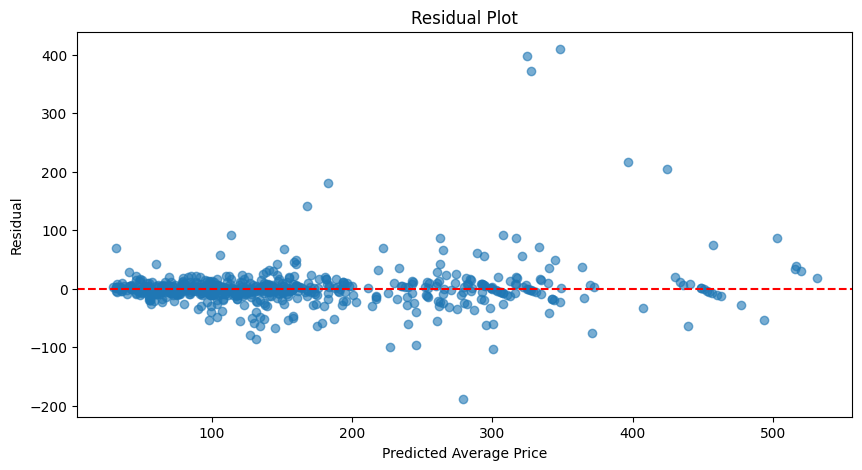

In [13]:
results["Residual"] = (
    results["Actual_Avg_Price_next"] -
    results["Predicted_Avg_Price_next"]
)

plt.figure(figsize=(10,5))

plt.scatter(
    results["Predicted_Avg_Price_next"],
    results["Residual"],
    alpha=0.6
)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Average Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

In [14]:
results["MAPE"] = (
    abs(
        (results["Actual_Avg_Price_next"] -
         results["Predicted_Avg_Price_next"])
        / results["Actual_Avg_Price_next"]
    )
) * 100

print(f"Average MAPE: {results['MAPE'].mean():.2f}%")

Average MAPE: 11.90%


In [15]:
best_cases = results.sort_values(
    by="Total_Error"
).head(20)

best_cases

,Product_Name,month_idx,Actual_Min_Price_next,Predicted_Min_Price_next,Actual_Avg_Price_next,Predicted_Avg_Price_next,Actual_Max_Price_next,Predicted_Max_Price_next,Min_Error,Avg_Error,Max_Error,Total_Error,Residual,MAPE
536,Smooth_Gourd,3,100.0,100.08,127.11,127.56,160.0,159.57,0.08,0.45,0.43,0.96,-0.45,0.354024
79,Bayar,4,100.0,101.24,110.00,109.61,120.0,120.01,1.24,0.39,0.01,1.64,0.39,0.354545
465,Potato_R,7,30.0,29.50,33.30,31.93,40.0,39.75,0.50,1.37,0.25,2.12,1.37,4.114114
88,Beat_Chukunder,7,80.0,79.74,100.00,99.80,120.0,121.85,0.26,0.20,1.85,2.31,0.20,0.200000
582,Sugarcane,7,160.0,159.39,165.00,164.06,170.0,171.16,0.61,0.94,1.16,2.71,0.94,0.569697
223,Cucumber,4,50.0,51.34,106.58,105.72,150.0,149.05,1.34,0.86,0.95,3.15,0.86,0.806906
458,Potato_Blue,5,40.0,39.31,43.47,43.37,50.0,52.47,0.69,0.10,2.47,3.26,0.10,0.230044
385,Onion_Dry,4,30.0,32.76,41.97,41.50,60.0,60.05,2.76,0.47,0.05,3.28,0.47,1.119848
486,Pumpkin_Green,5,70.0,67.44,80.00,80.02,90.0,89.12,2.56,0.02,0.88,3.46,-0.02,0.025000
633,Watermelon,4,60.0,61.94,67.11,67.03,80.0,78.50,1.94,0.08,1.50,3.52,0.08,0.119207
